In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0)

<Axes: xlabel='0', ylabel='1'>

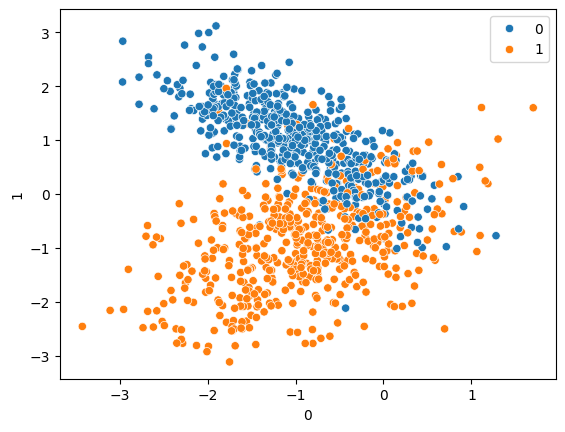

In [4]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,Y_test = train_test_split(X,y,test_size=.25,random_state=10)

In [6]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')

In [7]:
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [8]:
y

array([0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,

In [9]:
y_pred = svc.predict(X_test)


In [11]:
from sklearn.metrics import confusion_matrix,classification_report
CM = confusion_matrix(Y_test,y_pred)
print(CM)
report = classification_report(Y_test,y_pred)
print(report)

[[117  15]
 [ 15 103]]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       132
           1       0.87      0.87      0.87       118

    accuracy                           0.88       250
   macro avg       0.88      0.88      0.88       250
weighted avg       0.88      0.88      0.88       250



### now we will use different types of kernels


In [12]:
rbf = SVC(kernel='rbf')
rbf.fit(X_train,y_train)

SVC()

In [ ]:
y_pred = rbf.predict(X_test)

In [14]:
CM = confusion_matrix(Y_test,y_pred)
print(CM)
report = classification_report(Y_test,y_pred)
print(report)

[[119  13]
 [ 14 104]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       132
           1       0.89      0.88      0.89       118

    accuracy                           0.89       250
   macro avg       0.89      0.89      0.89       250
weighted avg       0.89      0.89      0.89       250



In [15]:
sig = SVC(kernel='sigmoid')
sig.fit(X_train,y_train)
y_pred = sig.predict(X_test)

In [16]:
CM = confusion_matrix(Y_test,y_pred)
print(CM)
report = classification_report(Y_test,y_pred)
print(report)

[[106  26]
 [ 28  90]]
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       132
           1       0.78      0.76      0.77       118

    accuracy                           0.78       250
   macro avg       0.78      0.78      0.78       250
weighted avg       0.78      0.78      0.78       250



In [17]:
poly = SVC(kernel='poly')
poly.fit(X_train,y_train)
y_pred = poly.predict(X_test)

In [18]:
CM = confusion_matrix(Y_test,y_pred)
print(CM)
report = classification_report(Y_test,y_pred)
print(report)

[[106  26]
 [ 15 103]]
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       132
           1       0.80      0.87      0.83       118

    accuracy                           0.84       250
   macro avg       0.84      0.84      0.84       250
weighted avg       0.84      0.84      0.84       250



In [20]:
## hyperparameter tunning
from sklearn.model_selection import GridSearchCV
params = {'C':[0.1,1,10,100],
           'gamma':[1,0.1,0.01,0.001,0.001],
           'kernel':['rbf']}


In [21]:
grid = GridSearchCV(estimator=SVC(),param_grid=params,cv = 5)

In [22]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.001],
                         'kernel': ['rbf']})

In [23]:
y_pred = grid.predict(X_test)

In [24]:
CM = confusion_matrix(Y_test,y_pred)
print(CM)
report = classification_report(Y_test,y_pred)
print(report)

[[119  13]
 [ 13 105]]
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       132
           1       0.89      0.89      0.89       118

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250

